## Setup

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import requests

import warnings
warnings.filterwarnings("ignore")
import os
from pathlib import Path
import sys
project_root = Path().resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    print(f"Added {project_root.stem} to sys.path")

from src.utils.llama import DefiLlamaAPI

llama = DefiLlamaAPI()


Added stables to sys.path


## total supply

In [3]:
# df_total_supply = llama.get_total_supply()
df_total_supply = df_total_supply.drop(['circulatingPrevWeek', 'circulatingPrevMonth'])#.sort('change_24h_pct', descending=True)


In [12]:
df_total_supply

id,name,symbol,gecko_id,pegType,priceSource,pegMechanism,circulating,circulatingPrevDay,change_24h,change_24h_pct
str,str,str,str,str,str,str,f64,f64,f64,f64
"""1""","""Tether""","""USDT""","""tether""","""peggedUSD""","""defillama""","""fiat-backed""",1.2032e11,1.2032e11,2.3496e6,0.0
"""2""","""USD Coin""","""USDC""","""usd-coin""","""peggedUSD""","""defillama""","""fiat-backed""",3.4367e10,3.4353e10,1.4048e7,0.04
"""5""","""Dai""","""DAI""","""dai""","""peggedUSD""","""defillama""","""crypto-backed""",4.9294e9,4.9310e9,-1.6078e6,-0.03
"""146""","""Ethena USDe""","""USDe""","""ethena-usde""","""peggedUSD""","""coingecko""","""crypto-backed""",2.6207e9,2.6215e9,-830323.182312,-0.03
"""119""","""First Digital USD""","""FDUSD""","""first-digital-usd""","""peggedUSD""","""defillama""","""fiat-backed""",2.2777e9,2.3061e9,-2.8397e7,-1.23
…,…,…,…,…,…,…,…,…,…,…
"""182""","""Zunami ETH""","""zunETH""","""zunETH""","""peggedVAR""","""defillama""","""crypto-backed""",null,null,null,null
"""183""","""Bitcoin USD""","""BtcUSD""","""bitcoin-usd-btcfi""","""peggedVAR""","""defillama""","""crypto-backed""",null,null,null,null
"""186""","""International Stable Currency""","""ISC""","""international-stable-currency""","""peggedVAR""","""coingecko""","""fiat-backed""",null,null,null,null


In [15]:
df_total_supply.filter(
    (abs(pl.col('change_24h_pct')) > 5) 
    & (pl.col('circulating') > 1e6)
).sort('change_24h_pct', descending=True)

id,name,symbol,gecko_id,pegType,priceSource,pegMechanism,circulating,circulatingPrevDay,change_24h,change_24h_pct
str,str,str,str,str,str,str,f64,f64,f64,f64
"""202""","""Anzen USDz""","""USDz""","""anzen-usdz""","""peggedUSD""","""defillama""","""fiat-backed""",8.1329e7,7.5330e7,5.9986e6,7.96
"""112""","""USDT+""","""USDT+""","""usdtplus""","""peggedUSD""","""defillama""","""crypto-backed""",2.9851e6,3.1586e6,-173487.851377,-5.49
"""22""","""sUSD""","""SUSD""","""nusd""","""peggedUSD""","""defillama""","""crypto-backed""",3.0834e7,3.3785e7,-2.9513e6,-8.74



Cluster 0:
shape: (105, 4)
┌──────────────────────┬────────┬────────────────┬────────────────┐
│ name                 ┆ symbol ┆ change_24h     ┆ change_24h_pct │
│ ---                  ┆ ---    ┆ ---            ┆ ---            │
│ str                  ┆ str    ┆ f64            ┆ f64            │
╞══════════════════════╪════════╪════════════════╪════════════════╡
│ PXDC Stablecoin      ┆ PXDC   ┆ -18868.907592  ┆ -1.53          │
│ Gemini Dollar        ┆ GUSD   ┆ -1.0256e6      ┆ -1.42          │
│ GRAI                 ┆ GRAI   ┆ -46763.379204  ┆ -1.31          │
│ Magic Internet Money ┆ MIM    ┆ -766337.927739 ┆ -1.31          │
│ PayPal USD           ┆ PYUSD  ┆ -7.8994e6      ┆ -1.25          │
│ …                    ┆ …      ┆ …              ┆ …              │
│ USDD                 ┆ USDD   ┆ 5.5652e6       ┆ 0.74           │
│ High Yield USD       ┆ HYUSD  ┆ 90744.437507   ┆ 0.97           │
│ Nexus USD            ┆ NUSD   ┆ 98114.360478   ┆ 1.11           │
│ Ondo US Dollar Yie

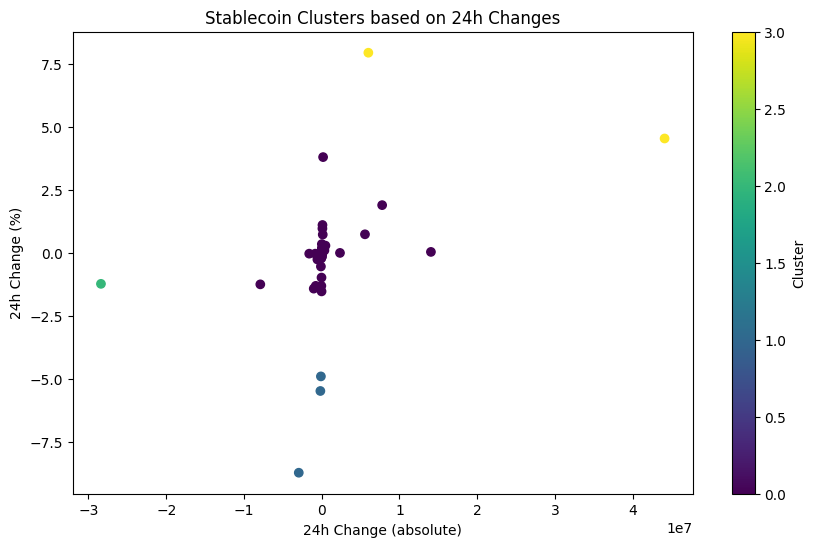

In [17]:
# ... existing imports ...
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare data for clustering
clustering_data = df_total_supply.select([
    'name', 'symbol', 'change_24h', 'change_24h_pct', 'circulating'
]).filter(
    pl.col('change_24h').is_not_null() 
    & pl.col('change_24h_pct').is_not_null()
    & (pl.col('circulating') > 1e6)  # Filter out very small stablecoins
)

# Convert to numpy array for sklearn
features = clustering_data.select(['change_24h', 'change_24h_pct']).to_numpy()

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform K-means clustering
n_clusters = 4  # You can adjust this number
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(features_scaled)

# Add cluster labels back to the dataframe
result = clustering_data.with_columns(
    pl.Series(name='cluster', values=clusters)
).sort(['cluster', 'change_24h_pct'])

# Display results by cluster
for i in range(n_clusters):
    print(f"\nCluster {i}:")
    print(result.filter(pl.col('cluster') == i).select(
        ['name', 'symbol', 'change_24h', 'change_24h_pct']
    ))

# Optional: Visualize clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(features[:, 0], features[:, 1], c=clusters, cmap='viridis')
plt.xlabel('24h Change (absolute)')
plt.ylabel('24h Change (%)')
plt.title('Stablecoin Clusters based on 24h Changes')
plt.colorbar(scatter, label='Cluster')
plt.show()

## big movers

In [24]:
import plotly.express as px

fig = px.scatter(
    df_total_supply,
    x='change_24h_pct',
    y='change_24h',
    opacity=0.5,
    color_discrete_sequence=['blue'],
    labels={
        'change_24h_pct': '24h Change (%)',
        'change_24h': '24h Change'
    },
    title='Stablecoin 24h Changes'
)
fig.show()



In [37]:
df_total_supply.filter(
    (abs(pl.col('change_24h')) > 1e6)
    & (abs(pl.col('change_24h_pct')) > 4.5)
)#.sort('change_24h_pct', descending=True)


id,name,symbol,gecko_id,pegType,priceSource,pegMechanism,circulating,circulatingPrevDay,change_24h,change_24h_pct
str,str,str,str,str,str,str,f64,f64,f64,f64
"""202""","""Anzen USDz""","""USDz""","""anzen-usdz""","""peggedUSD""","""defillama""","""fiat-backed""",8.1329e7,7.5330e7,5.9986e6,7.96
"""209""","""Sky Dollar""","""USDS""","""usds""","""peggedUSD""","""defillama""","""crypto-backed""",1.0125e9,9.6836e8,4.4107e7,4.55
"""22""","""sUSD""","""SUSD""","""nusd""","""peggedUSD""","""defillama""","""crypto-backed""",3.0834e7,3.3785e7,-2.9513e6,-8.74


In [38]:
ll = df_total_supply.filter(
    (abs(pl.col('change_24h')) > 1e6)
    & (abs(pl.col('change_24h_pct')) > 4.5)
)['name'].to_list()


In [27]:
df_chains = llama.get_chain_circulation()


In [28]:
df_chains.filter(
    pl.col('change_24h').is_not_null()
    & (pl.col('change_24h') != 0.0)
).sort('change_24h_pct', descending=True)


coin,symbol,chain,current,prev_day,price,change_24h,change_24h_pct
str,str,str,f64,f64,f64,f64,f64
"""Ondo US Dollar Yield""","""USDY""","""Sui""",7.7732e6,0.0,1.064635,7.7732e6,inf
"""Ethena USDe""","""USDe""","""BSC""",2548.555315,1408.84567,0.999435,1139.709645,80.9
"""Anzen USDz""","""USDz""","""Ethereum""",2.2954e7,1.6952e7,1.002,6.0014e6,35.4
"""Ethena USDe""","""USDe""","""Kava""",33.812821,25.539751,0.999435,8.27307,32.39
"""Tether""","""USDT""","""Taiko""",1.6540e6,1.3530e6,0.998581,301000.102403,22.25
…,…,…,…,…,…,…,…
"""sUSD""","""SUSD""","""Optimism""",1.9843e7,2.2301e7,0.999898,-2.4577e6,-11.02
"""USD Coin""","""USDC""","""Waves""",32454.308355,37601.344759,0.999818,-5147.036404,-13.69
"""Verified USD""","""USDV""","""Arbitrum""",162012.703839,193797.642203,1.0,-31784.938364,-16.4


In [43]:
df_chains.filter(
    pl.col('coin').is_in(ll)
    & (pl.col('change_24h') != 0.0)
)#.sort('change_24h_pct', descending=True)


coin,symbol,chain,current,prev_day,price,change_24h,change_24h_pct
str,str,str,f64,f64,f64,f64,f64
"""sUSD""","""SUSD""","""Optimism""",1.9843e7,2.2301e7,0.999898,-2.4577e6,-11.02
"""sUSD""","""SUSD""","""Ethereum""",1.0991e7,1.1484e7,0.999898,-493541.893717,-4.3
"""Anzen USDz""","""USDz""","""Ethereum""",2.2954e7,1.6952e7,1.002,6.0014e6,35.4
"""Anzen USDz""","""USDz""","""Manta""",651854.839999,651823.818829,1.002,31.02117,0.0
"""Anzen USDz""","""USDz""","""Blast""",132440.07272,132821.78545,1.002,-381.71273,-0.29
"""Anzen USDz""","""USDz""","""Base""",5.7590e7,5.7593e7,1.002,-2443.94746,-0.0
"""Sky Dollar""","""USDS""","""Ethereum""",1.0125e9,9.6836e8,1.009,4.4107e7,4.55
